## Ahmed Series One

In [1]:
from experiment_analysis import experiments_from_series

[161, 162, 163, 164]


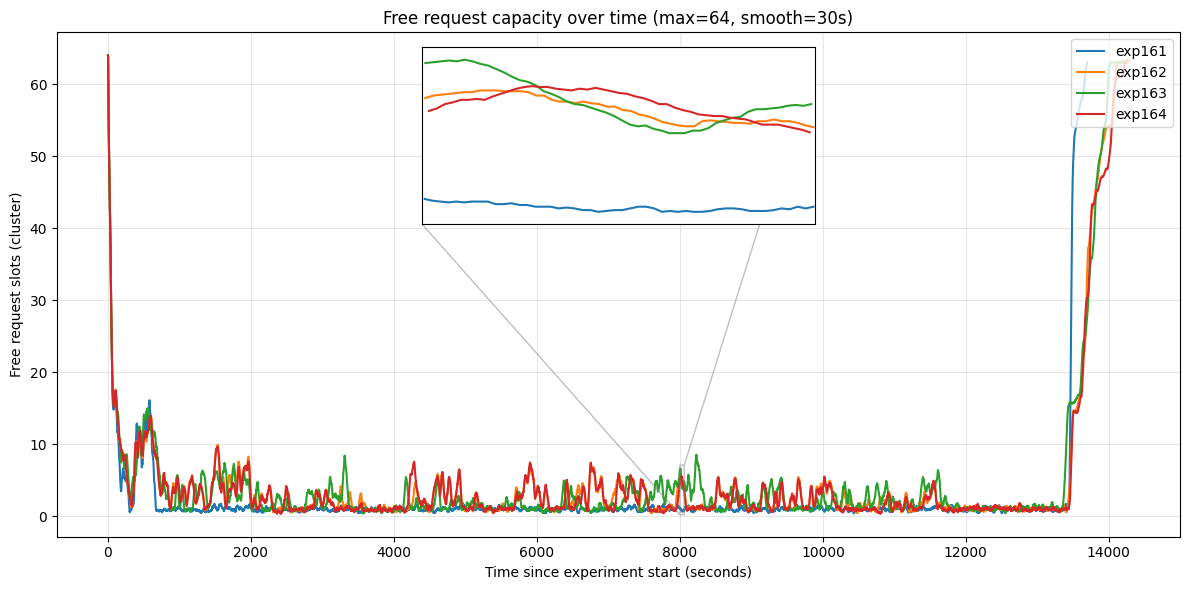

In [2]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import os

# ---- choose experiments ----
series_ids = [40]
experiments = experiments_from_series(series_ids)
print(experiments)
# ----------------------------

metric = "requests_running"
MAX_REQUEST_CAPACITY = 64
SMOOTHING_WINDOW_S = 30

agg_mode = "sum"
# agg_mode = "mean"

# ---- magnifier zoom window in TIME ----
ZOOM_T_START = 8000
ZOOM_T_END   = 8060

# ---- inset box placement in AXES coordinates (guaranteed inside) ----
# [x0, y0, width, height] all in 0..1 relative to the main axes
INSET_RECT = [0.325, 0.62, 0.35, 0.35]   # upper-middle, 35% size (same as before)
# -----------------------------------------------

plt.figure(figsize=(12, 6))
ax = plt.gca()

series_by_exp = {}

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    if agg_mode == "sum":
        running = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        capacity = MAX_REQUEST_CAPACITY
        y_label = "Free request slots (cluster)"
    else:
        running = prom.groupby("t_rel_s")[metric].mean()
        capacity = MAX_REQUEST_CAPACITY
        y_label = "Free request slots (per instance avg)"

    free_slots = (capacity - running).clip(lower=0)

    if SMOOTHING_WINDOW_S and SMOOTHING_WINDOW_S > 1:
        free_slots = free_slots.rolling(window=SMOOTHING_WINDOW_S, min_periods=1).mean()

    ax.plot(free_slots.index, free_slots.values, label=f"exp{exp_id}")
    series_by_exp[exp_id] = free_slots

ax.set_xlabel("Time since experiment start (seconds)")
ax.set_ylabel(y_label)
ax.set_title(f"Free request capacity over time (max={MAX_REQUEST_CAPACITY}, smooth={SMOOTHING_WINDOW_S}s)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# ---- inset (magnifier) ----
if series_by_exp:
    axins = ax.inset_axes(INSET_RECT)  # <-- stays inside the main axes

    zoom_ymins, zoom_ymaxs = [], []

    for free_slots in series_by_exp.values():
        zoomed = free_slots.loc[(free_slots.index >= ZOOM_T_START) & (free_slots.index <= ZOOM_T_END)]
        if zoomed.empty:
            continue

        axins.plot(zoomed.index, zoomed.values)
        zoom_ymins.append(float(zoomed.min()))
        zoom_ymaxs.append(float(zoomed.max()))

    if zoom_ymins:
        axins.set_xlim(ZOOM_T_START, ZOOM_T_END)

        y0, y1 = min(zoom_ymins), max(zoom_ymaxs)
        pad = max(1e-9, 0.08 * (y1 - y0))
        axins.set_ylim(y0 - pad, y1 + pad)

        axins.set_xticks([])
        axins.set_yticks([])
        axins.grid(True, alpha=0.2)

        # Nice connector + zoom box (better than mark_inset for this use)
        ax.indicate_inset_zoom(axins, edgecolor="0.5")

plt.tight_layout()


os.makedirs("figures", exist_ok=True)
plt.savefig("figures/free_request_capacity_with_inset.png", dpi=300, bbox_inches="tight")




[161, 162, 163, 164]


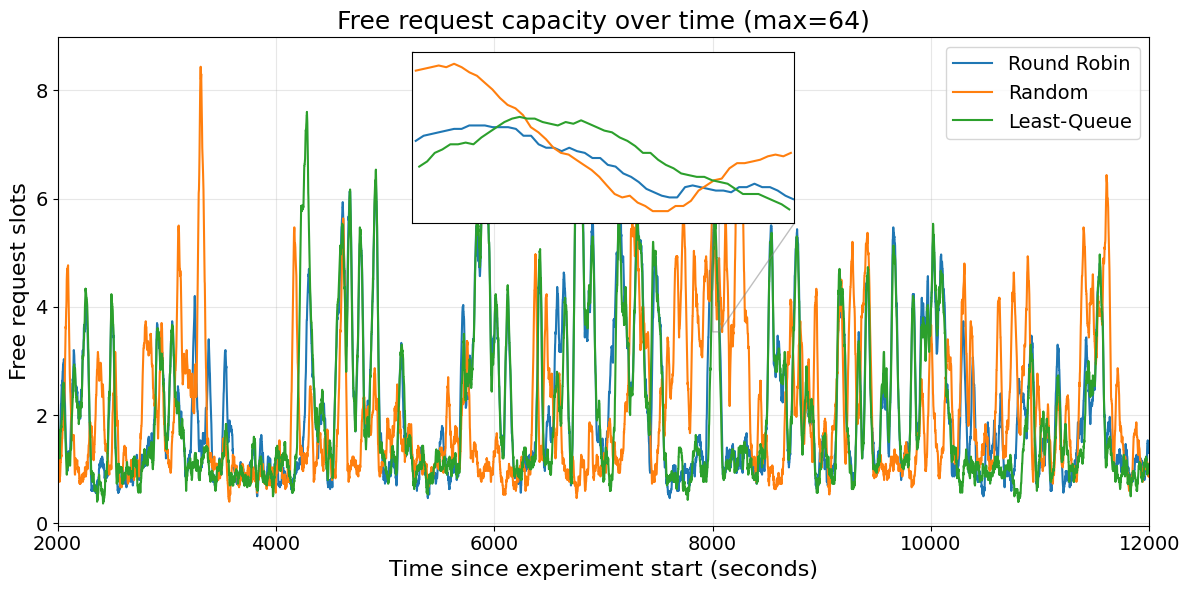

In [24]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import os

# ---- Global font size control ----
TITLE_FS = 18
LABEL_FS = 16
TICK_FS = 14
LEGEND_FS = 14
# -----------------------------------

# ---- choose experiments ----
series_ids = [40]
experiments = experiments_from_series(series_ids)
print(experiments)

LABELS = {
    162: "Round Robin",
    163: "Random",
    164: "Least-Queue",
}

experiments = [e for e in experiments if e != 161]

metric = "requests_running"
MAX_REQUEST_CAPACITY = 64
SMOOTHING_WINDOW_S = 30
agg_mode = "sum"

DRAW_T_START = 2000
DRAW_T_END   = 12000

ZOOM_T_START = 8000
ZOOM_T_END   = 8060

INSET_RECT = [0.325, 0.62, 0.35, 0.35]

plt.figure(figsize=(12, 6))
ax = plt.gca()

series_by_exp = {}

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)

    if prom.empty:
        continue
    if metric not in prom.columns:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    if agg_mode == "sum":
        running = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        capacity = MAX_REQUEST_CAPACITY
        y_label = "Free request slots"
    else:
        running = prom.groupby("t_rel_s")[metric].mean()
        capacity = MAX_REQUEST_CAPACITY
        y_label = "Free request slots (per instance avg)"

    free_slots = (capacity - running).clip(lower=0)

    if SMOOTHING_WINDOW_S and SMOOTHING_WINDOW_S > 1:
        free_slots = free_slots.rolling(window=SMOOTHING_WINDOW_S, min_periods=1).mean()

    free_slots_plot = free_slots.loc[
        (free_slots.index >= DRAW_T_START) & (free_slots.index <= DRAW_T_END)
    ]
    if free_slots_plot.empty:
        continue

    label = LABELS.get(exp_id, f"exp{exp_id}")
    ax.plot(free_slots_plot.index, free_slots_plot.values, label=label)

    series_by_exp[exp_id] = free_slots

# ---- Larger fonts applied here ----
ax.set_xlabel("Time since experiment start (seconds)", fontsize=LABEL_FS)
ax.set_ylabel(y_label, fontsize=LABEL_FS)
ax.set_title(
    # f"Free request capacity over time (max={MAX_REQUEST_CAPACITY}, smooth={SMOOTHING_WINDOW_S}s)",
    f"Free request capacity over time (max={MAX_REQUEST_CAPACITY})",
    fontsize=TITLE_FS,
)

ax.tick_params(axis='both', labelsize=TICK_FS)

ax.legend(loc="upper right", fontsize=LEGEND_FS)
ax.grid(True, alpha=0.3)
ax.set_xlim(DRAW_T_START, DRAW_T_END)

# ---- inset ----
if series_by_exp:
    axins = ax.inset_axes(INSET_RECT)

    zoom_ymins, zoom_ymaxs = [], []

    for exp_id, free_slots in series_by_exp.items():
        zoomed = free_slots.loc[
            (free_slots.index >= ZOOM_T_START) &
            (free_slots.index <= ZOOM_T_END)
        ]
        if zoomed.empty:
            continue

        axins.plot(zoomed.index, zoomed.values)
        zoom_ymins.append(float(zoomed.min()))
        zoom_ymaxs.append(float(zoomed.max()))

    if zoom_ymins:
        axins.set_xlim(ZOOM_T_START, ZOOM_T_END)

        y0, y1 = min(zoom_ymins), max(zoom_ymaxs)
        pad = max(1e-9, 0.08 * (y1 - y0))
        axins.set_ylim(y0 - pad, y1 + pad)

        axins.set_xticks([])
        axins.set_yticks([])
        axins.grid(True, alpha=0.2)

        ax.indicate_inset_zoom(axins, edgecolor="0.5")

plt.tight_layout()

os.makedirs("figures", exist_ok=True)
plt.savefig("figures/free_request_capacity_with_inset.png",
            dpi=300,
            bbox_inches="tight")

plt.show()


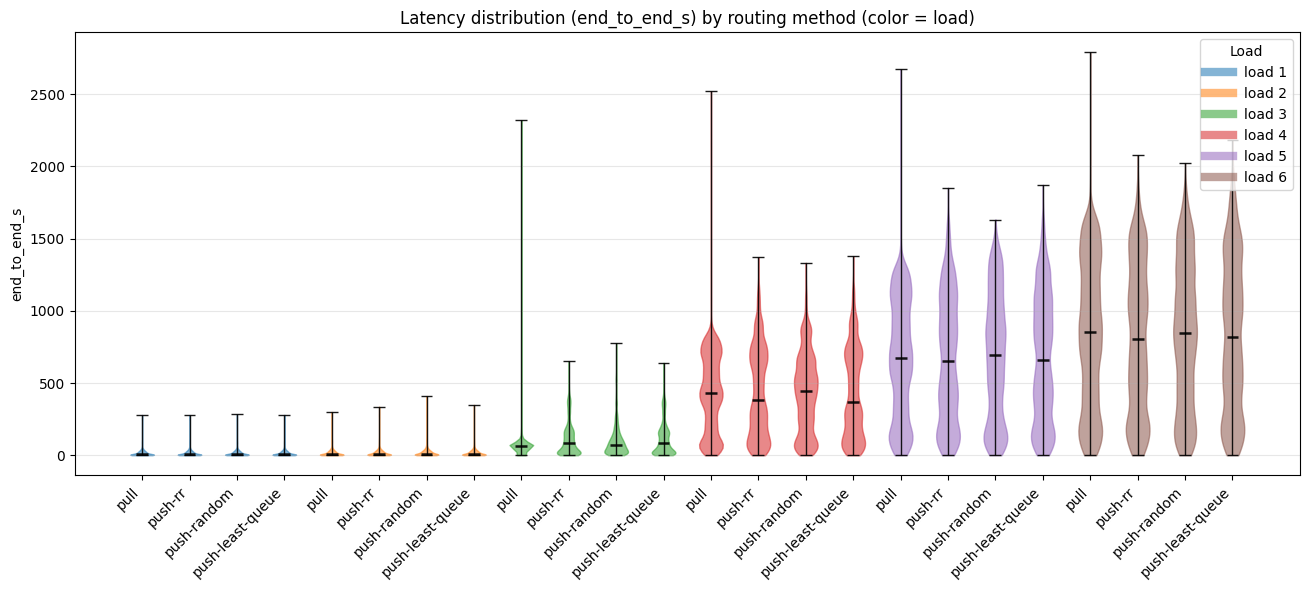

In [4]:
from experiment_analysis import load_experiment_latencies
import pandas as pd
import matplotlib.pyplot as plt
import os

# ---- choose series (one or more) ----
series_ids = [33, 34, 35, 36, 37, 38]
# ------------------------------------

# ---- map series id -> friendly name (your load levels) ----
series_display_name = {
    33: "load 1",
    34: "load 2",
    35: "load 3",
    36: "load 4",
    37: "load 5",
    38: "load 6",
}

# ---- within each series, which experiments to include? ----
exp_indices_in_series = [0, 1, 2, 3]

# ---- map exp index -> method name (fixed ordering within each series) ----
method_display_name = {
    0: "pull",
    1: "push-rr",
    2: "push-random",
    3: "push-least-queue",
}
# ------------------------------------

# ---- choose ONE latency metric (uncomment exactly one) ----
metric = "end_to_end_s"
# metric = "server_roundtrip_s"
# metric = "router_queue_s"
# metric = "vllm_compute_s"
# ------------------------------------

# Optional: clip extreme tail for nicer violins (set None to disable)
clip_pctl = None

# Style knobs
VIOLIN_ALPHA = 0.55
EDGE_ALPHA = 0.9
MEDIAN_LW = 1.8
EXTREMA_LW = 1.0

# -------------------- helper: resolve series -> experiments --------------------
series_to_exps = {}
for sid in series_ids:
    exps = list(experiments_from_series([sid]))
    if not exps:
        print(f"Skipping series {sid}: no experiments found")
        continue
    series_to_exps[sid] = exps

# -------------------- collect data --------------------
rows = []
labels = []          # x-axis labels (METHOD ONLY)
series_for_row = []  # which series each violin belongs to
method_for_row = []  # method index (0..3) for ordering/ticks

for sid in series_ids:
    if sid not in series_to_exps:
        continue

    exps = series_to_exps[sid]

    for i in exp_indices_in_series:
        if i < 0 or i >= len(exps):
            continue

        exp_id = exps[i]
        method_name = method_display_name.get(i, f"e{i}")

        df = load_experiment_latencies(exp_id=exp_id)
        if df.empty or metric not in df.columns:
            continue

        s = pd.to_numeric(df[metric], errors="coerce").dropna()
        if s.empty:
            continue

        if clip_pctl is not None:
            hi = s.quantile(clip_pctl / 100.0)
            s = s[s <= hi]

        rows.append(s.values)
        labels.append(method_name)      # <-- method only
        series_for_row.append(sid)
        method_for_row.append(i)

if not rows:
    raise RuntimeError("No experiments had usable latency data for the selected metric.")

# -------------------- plot violins --------------------
fig_w = max(12, 0.55 * len(rows))
plt.figure(figsize=(fig_w, 6))
ax = plt.gca()

positions = list(range(1, len(rows) + 1))

vp = ax.violinplot(
    rows,
    positions=positions,
    showmeans=False,
    showmedians=True,
    showextrema=True
)

# Color by load (series)
unique_series = [sid for sid in series_ids if sid in series_to_exps]
color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if not color_cycle:
    color_cycle = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"]
series_to_color = {sid: color_cycle[i % len(color_cycle)] for i, sid in enumerate(unique_series)}

for body, sid in zip(vp["bodies"], series_for_row):
    c = series_to_color[sid]
    body.set_facecolor(c)
    body.set_edgecolor(c)
    body.set_alpha(VIOLIN_ALPHA)
    body.set_linewidth(1.0)

# Median / extrema styling
if "cmedians" in vp:
    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(MEDIAN_LW)
    vp["cmedians"].set_alpha(EDGE_ALPHA)

for k in ("cmins", "cmaxes", "cbars"):
    if k in vp:
        vp[k].set_color("black")
        vp[k].set_linewidth(EXTREMA_LW)
        vp[k].set_alpha(EDGE_ALPHA)

# ---- X axis: show METHOD labels, repeated per violin ----
ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=45, ha="right")

ax.set_ylabel(metric)
title = f"Latency distribution ({metric}) by routing method (color = load)"
if clip_pctl is not None:
    title += f" (clipped above p{clip_pctl})"
ax.set_title(title)

ax.grid(True, axis="y", alpha=0.3)

# Legend: load → color (friendly names)
handles = []
legend_labels = []
for sid in unique_series:
    load_name = series_display_name.get(sid, f"series {sid}")
    h = plt.Line2D([0], [0], color=series_to_color[sid], lw=6, alpha=VIOLIN_ALPHA)
    handles.append(h)
    legend_labels.append(load_name)

ax.legend(handles, legend_labels, loc="upper right", title="Load")

plt.tight_layout()


os.makedirs("figures", exist_ok=True)

measure_name = "dist"   # distribution (violin)
fname = f"figures/{measure_name}_{metric}_by_method_by_load.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")

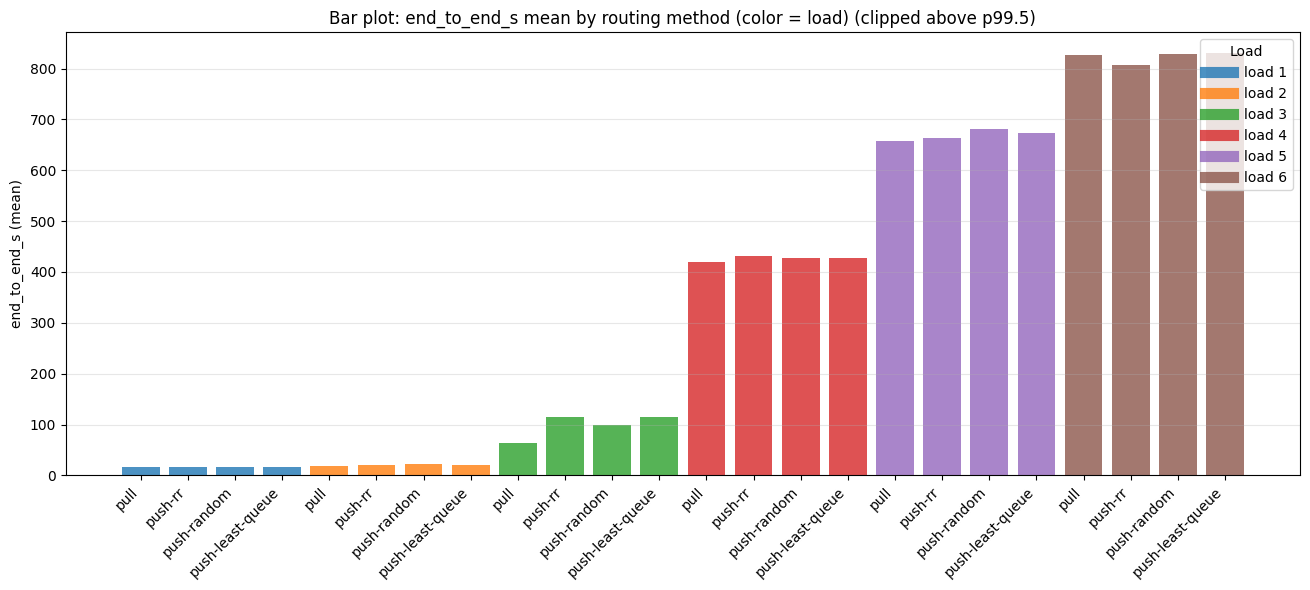

In [5]:
from experiment_analysis import load_experiment_latencies
import pandas as pd
import matplotlib.pyplot as plt
import os


# ---- choose series (one or more) ----
series_ids = [33, 34, 35, 36, 37, 38]
# ------------------------------------

# ---- map series id -> friendly name (your load levels) ----
series_display_name = {
    33: "load 1",
    34: "load 2",
    35: "load 3",
    36: "load 4",
    37: "load 5",
    38: "load 6",
}

# ---- within each series, which experiments to include? ----
exp_indices_in_series = [0, 1, 2, 3]

# ---- map exp index -> method name (fixed ordering within each series) ----
method_display_name = {
    0: "pull",
    1: "push-rr",
    2: "push-random",
    3: "push-least-queue",
}
# ------------------------------------

# ---- choose ONE latency metric (uncomment exactly one) ----
metric = "end_to_end_s"
# metric = "server_roundtrip_s"
# metric = "router_queue_s"
# metric = "vllm_compute_s"
# ------------------------------------

# ---- choose ONE stat at a time ----
stat_to_plot = "mean"     # <- pick ONE: "50%", "90%", "99%", "mean", etc.

# Optional: clip extreme tail before computing stats (set None to disable)
clip_pctl = 99.5  # e.g. 99.5; or None

# -------------------- resolve series -> experiments --------------------
series_to_exps = {}
for sid in series_ids:
    exps = list(experiments_from_series([sid]))
    if not exps:
        print(f"Skipping series {sid}: no experiments found")
        continue
    series_to_exps[sid] = exps

# -------------------- compute stat per experiment --------------------
records = []  # each: {series, method_idx, method, value}

for sid in series_ids:
    if sid not in series_to_exps:
        continue

    exps = series_to_exps[sid]

    for i in exp_indices_in_series:
        if i < 0 or i >= len(exps):
            print(f"Skipping series {sid} exp_index {i}: out of range (len={len(exps)})")
            continue

        exp_id = exps[i]
        df = load_experiment_latencies(exp_id=exp_id)

        if df.empty or metric not in df.columns:
            print(f"Skipping series {sid} exp_index {i}: no data or missing {metric}")
            continue

        s = pd.to_numeric(df[metric], errors="coerce").dropna()
        if s.empty:
            print(f"Skipping series {sid} exp_index {i}: {metric} all NaN")
            continue

        if clip_pctl is not None:
            hi = s.quantile(clip_pctl / 100.0)
            s = s[s <= hi]

        # Compute exactly the stat requested
        if stat_to_plot.endswith("%"):
            q = float(stat_to_plot.strip("%")) / 100.0
            val = float(s.quantile(q))
        else:
            if stat_to_plot == "mean":
                val = float(s.mean())
            elif stat_to_plot == "std":
                val = float(s.std())
            elif stat_to_plot == "min":
                val = float(s.min())
            elif stat_to_plot == "max":
                val = float(s.max())
            else:
                raise ValueError("stat_to_plot must be a percentile like '90%' or one of: mean, std, min, max")

        records.append({
            "series": sid,
            "method_idx": i,
            "method": method_display_name.get(i, f"e{i}"),
            "value": val,
        })

if not records:
    raise RuntimeError("No experiments had usable latency data for the selected metric/stat.")

plot_df = pd.DataFrame.from_records(records)

# Order bars: by series_ids, then method order
series_rank = {sid: r for r, sid in enumerate(series_ids)}
plot_df["series_rank"] = plot_df["series"].map(series_rank)
plot_df = plot_df.sort_values(["series_rank", "method_idx"]).reset_index(drop=True)

# X-axis labels: METHOD ONLY (no series/load, no exp id)
x_labels = plot_df["method"].tolist()

# -------------------- color by series (load) --------------------
unique_series = [sid for sid in series_ids if sid in plot_df["series"].unique()]
color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if not color_cycle:
    color_cycle = ["C0", "C1", "C2", "C3", "C4", "C5", "C6", "C7", "C8", "C9"]
series_to_color = {sid: color_cycle[j % len(color_cycle)] for j, sid in enumerate(unique_series)}

colors = [series_to_color[sid] for sid in plot_df["series"].tolist()]

# -------------------- plot --------------------
fig_w = max(12, 0.55 * len(plot_df))
plt.figure(figsize=(fig_w, 6))
ax = plt.gca()

x = list(range(len(plot_df)))
ax.bar(x, plot_df["value"].values, color=colors, alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=45, ha="right")
ax.set_ylabel(f"{metric} ({stat_to_plot})")

title = f"Bar plot: {metric} {stat_to_plot} by routing method (color = load)"
if clip_pctl is not None:
    title += f" (clipped above p{clip_pctl})"
ax.set_title(title)

ax.grid(True, axis="y", alpha=0.3)

# Legend: load → color (friendly names)
handles = []
legend_labels = []
for sid in unique_series:
    load_name = series_display_name.get(sid, f"series {sid}")
    h = plt.Line2D([0], [0], color=series_to_color[sid], lw=8, alpha=0.8)
    handles.append(h)
    legend_labels.append(load_name)

ax.legend(handles, legend_labels, loc="upper right", frameon=True, title="Load")

plt.tight_layout()

measure_name = stat_to_plot.replace("%", "").lower()
if stat_to_plot.endswith("%"):
    measure_name = f"p{measure_name}"   # "99%" -> "p99"
# else: "mean", "std", "min", "max" stay as-is

fname = f"figures/{measure_name}_{metric}_by_method_by_load.png"
plt.savefig(fname, dpi=300, bbox_inches="tight")


[141, 142, 143, 144]


/tmp/ipykernel_366694/829307318.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(canonical_slots))


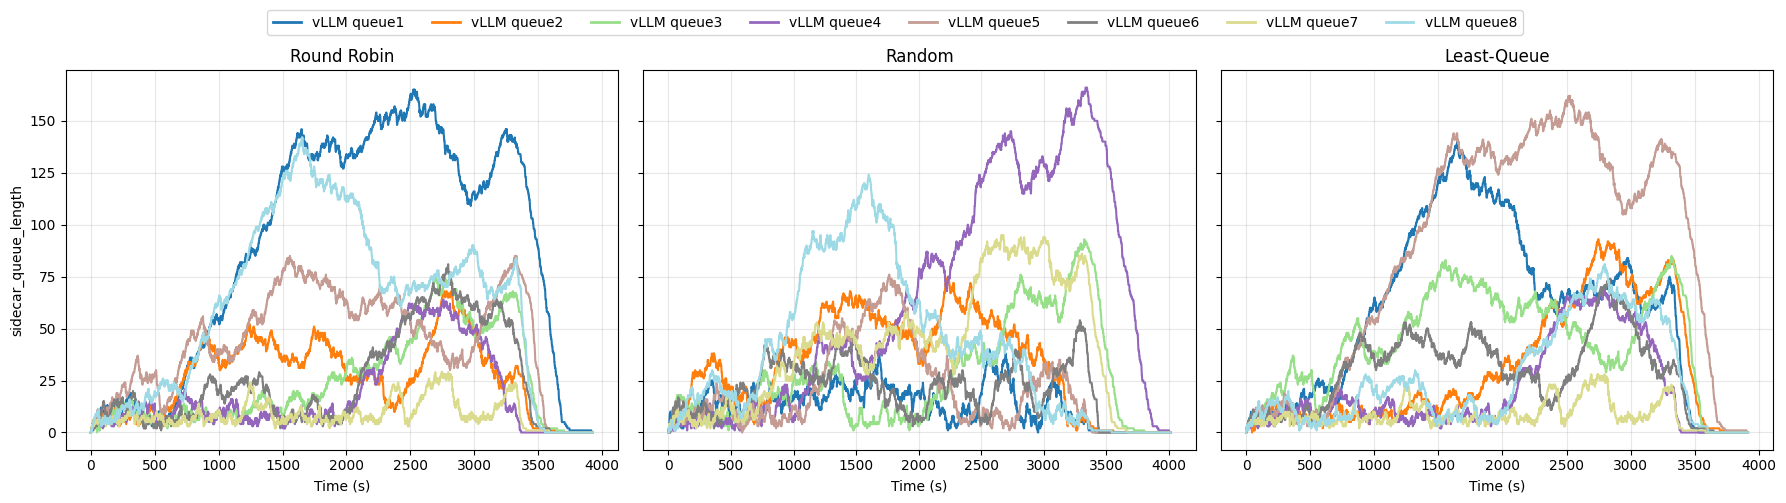

In [20]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
print(experiments)

LABELS = {
    142: "Round Robin",
    143: "Random",
    144: "Least-Queue",
}

experiments = [e for e in experiments if e in LABELS]


# ============================================================
# Choose ONE metric
# ============================================================
metric = "sidecar_queue_length"

view = "vllm"  # sidecar_* live on vLLM (:8200)


def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]

# Pretty legend names
legend_names = [f"vLLM queue{i}" for i in range(1, max_servers + 1)]


# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = cm.get_cmap("tab20", len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}


# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.set_title(f"{LABELS[exp_id]}\n(no data)")
        ax.grid(True, alpha=0.3)
        continue

    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )

    ax.set_title(LABELS[exp_id])
    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(metric)

# ------------------------------------------------------------
# Unified legend (renamed)
# ------------------------------------------------------------
handles = [
    plt.Line2D([0], [0], color=color_map[slot], lw=2)
    for slot in canonical_slots
]

fig.legend(
    handles,
    legend_names,   # renamed here
    loc="upper center",
    ncol=min(len(legend_names), 8),
    bbox_to_anchor=(0.5, 1.01),
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)

plt.show()


[141, 142, 143, 144]


/tmp/ipykernel_366694/3036676866.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(canonical_slots))


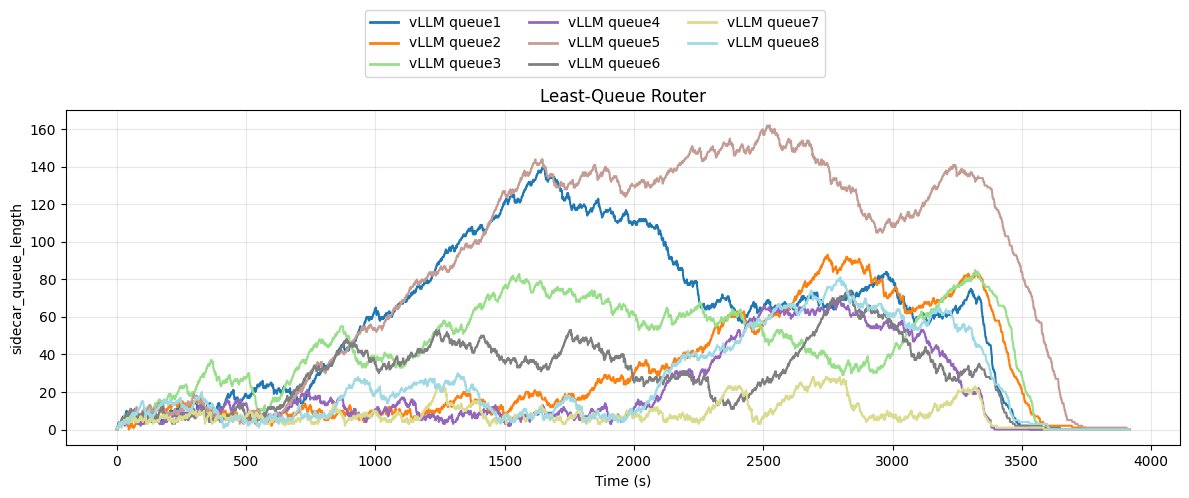

In [31]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
print(experiments)

LABELS = {
    142: "Round Robin",
    143: "Random",
    144: "Least-Queue Router",
}

# ONLY keep Least-Queue
experiments = [e for e in experiments if e == 144]


# ============================================================
# Choose ONE metric
# ============================================================
metric = "sidecar_queue_length"
view = "vllm"  # sidecar_* live on vLLM (:8200)


def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# Load data + assign server1..serverN (single experiment)
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]
legend_names = [f"vLLM queue{i}" for i in range(1, max_servers + 1)]


# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = cm.get_cmap("tab20", len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}


# ------------------------------------------------------------
# Plot single panel (Least-Queue)
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

exp_id = 144
df = data_by_exp.get(exp_id)

if df is None or df.empty:
    ax.set_title(f"{LABELS[exp_id]}\n(no data)")
    ax.grid(True, alpha=0.3)
else:
    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )

    ax.set_title(LABELS[exp_id])
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Unified legend on top, forced to 3 rows
# ------------------------------------------------------------
handles = [plt.Line2D([0], [0], color=color_map[slot], lw=2) for slot in canonical_slots]

# Force legend into 3 rows by choosing columns
n_items = len(legend_names)
ncol = max(1, (n_items + 3 - 1) // 3)  # ceil(n_items / 3)

fig.legend(
    handles,
    legend_names,
    loc="upper center",
    ncol=ncol,
    bbox_to_anchor=(0.5, 1),
)

# Reserve a bit more top space for 3 legend lines
plt.tight_layout(rect=[0, 0, 1, 0.86])

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
plt.savefig(f"figures/{metric}_least_queue_per_vllm_queue.png", dpi=300)

plt.show()


[141, 142, 143, 144]


/tmp/ipykernel_366694/1521282361.py:95: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(canonical_slots))


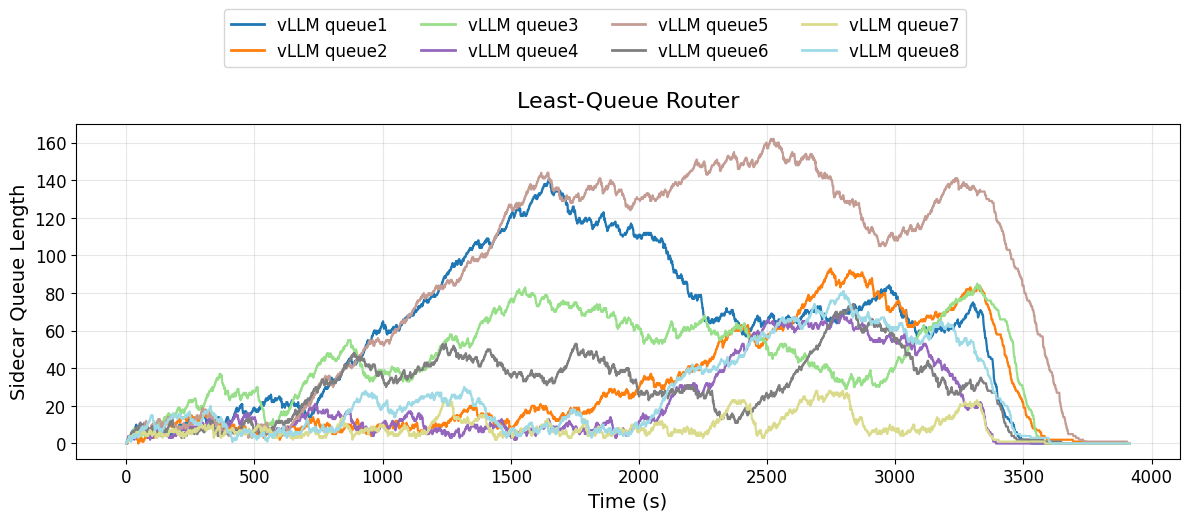

In [34]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os
import math

# ----------------------------
# Modest font sizes
# ----------------------------
TITLE_FS  = 16
LABEL_FS  = 14
TICK_FS   = 12
LEGEND_FS = 12
# ----------------------------

# ---- choose experiments ----
series_ids = [35]
experiments = experiments_from_series(series_ids)
print(experiments)

LABELS = {
    142: "Round Robin",
    143: "Random",
    144: "Least-Queue Router",
}

# ONLY keep Least-Queue
experiments = [e for e in experiments if e == 144]

# ============================================================
# Choose ONE metric
# ============================================================
metric = "sidecar_queue_length"
view = "vllm"

# Pretty Y label (remove underscores/dashes)
y_label_clean = metric.replace("_", " ").replace("-", " ").title()


def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# Load data + assign server1..serverN
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id)
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]
legend_names = [f"vLLM queue{i}" for i in range(1, max_servers + 1)]

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------
cmap = cm.get_cmap("tab20", len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

exp_id = 144
df = data_by_exp.get(exp_id)

if df is None or df.empty:
    ax.set_title(f"{LABELS[exp_id]}\n(no data)", fontsize=TITLE_FS)
    ax.grid(True, alpha=0.3)
else:
    for slot, g in df.groupby("server_slot"):
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.6,
        )

    ax.set_title(LABELS[exp_id], fontsize=TITLE_FS, pad=12)
    ax.set_xlabel("Time (s)", fontsize=LABEL_FS)
    ax.set_ylabel(y_label_clean, fontsize=LABEL_FS)
    ax.tick_params(axis='both', labelsize=TICK_FS)
    ax.grid(True, alpha=0.3)

# ------------------------------------------------------------
# Legend (FORCED to exactly 2 rows)
# ------------------------------------------------------------
handles = [
    plt.Line2D([0], [0], color=color_map[slot], lw=2)
    for slot in canonical_slots
]

n_items = len(legend_names)
ncol = math.ceil(n_items / 2)  # force exactly 2 rows

fig.legend(
    handles,
    legend_names,
    loc="upper center",
    ncol=ncol,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=LEGEND_FS,
)

plt.tight_layout(rect=[0, 0, 1, 0.90])

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
plt.savefig(
    f"figures/{metric}_least_queue_per_vllm_queue.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1
)


plt.show()
